# Historical Aggregation — Monthly Cubes for Modeling

Roll the cleaned fact table from `0_clean_historical.ipynb` into two month-grain cubes that downstream notebooks (`2_*` features, `3_*` modeling) train on.

- **`historical_fingerprint.parquet`** — one row per `(month, item-fingerprint)`. The fingerprint is a 5-tuple `(product_type_id, gender_id, color_master_id, graphical_appearance_id, material_id)` chosen to match a real shopper-style item description (e.g. green dot canvas shorts, Women). Trains the **Item Forecaster** that powers the inventory-advisor feature.
- **`historical_univariate.parquet`** — one row per `(month, dimension, level_id)`. Stores per-feature monthly popularity for every dimension in `lookup.csv`. Trains the **univariate forecaster** that powers the univariate explorer feature.

Both share a `source` column (`'historical'` here, `'live'` once scrapers come online) so the future live-aggregation notebook concatenates cleanly. All temporal features are calendar-relative (`month_of_year`, plus lags built in `2_*`) — never absolute year — so the system works on any future window without retraining the encoding.

**Catalog-share only.** Popularity is measured as *distinct-article share of the monthly catalog* (`share_articles`). We persist `n_articles` as QA and optional weighting metadata, not as a required model feature. Transaction-grain quantities (`n_transactions`, `share_transactions`) are deliberately **not** persisted — live scrapers won't be able to produce them, and including them would either (a) introduce a feature that's perfectly correlated with `source` (modeling footgun) or (b) require imputing transaction shares from catalog shares for live data (an anti-pattern). If a one-off transaction-grain analysis is ever needed, recompute from `transactions.parquet` directly.

## Schema (the contract for both historical + future live cubes)

### `historical_fingerprint.parquet`

| column | dtype | notes |
|---|---|---|
| `month` | datetime64[ns] | month-start (e.g. `2019-03-01`) |
| `month_of_year` | int8 | 1..12, modeling feature for seasonality |
| `source` | category | `'historical'` \| `'live'` |
| `product_type_id` | int8 | fingerprint dim 1 |
| `gender_id` | int8 | fingerprint dim 2 |
| `color_master_id` | int8 | fingerprint dim 3 |
| `graphical_appearance_id` | int8 | fingerprint dim 4 |
| `material_id` | int8 | fingerprint dim 5 |
| `n_articles` | int32 | distinct articles with this combo this month (catalog grain) |
| `share_articles` | float32 | `n_articles / total catalog articles in month` |
| `avg_price` | float32 | mean price for this combo this month (live: NaN until scraper enrichment lands) |

Grain: one row per `(month, product_type_id, gender_id, color_master_id, graphical_appearance_id, material_id)`.

### `historical_univariate.parquet`

| column | dtype | notes |
|---|---|---|
| `month` | datetime64[ns] | month-start |
| `month_of_year` | int8 | 1..12 |
| `source` | category | `'historical'` \| `'live'` |
| `dimension` | category | one of: `product_type`, `product_group`, `graphical_appearance`, `color_master`, `color_spectrum`, `gender`, `material` |
| `level_id` | int8 | category id within `dimension`; decode via `lookup.csv` (`category=dimension, id=level_id`) |
| `n_articles` | int32 | distinct articles with this dimension=level this month (QA + optional sample-weight metadata) |
| `share_articles` | float32 | `n_articles / total catalog articles in month` |

Grain: one row per `(month, dimension, level_id)`. Long format — every dimension stacked.

### Metadata vs. model features

Two columns are row-level metadata, **not** model features. They exist so downstream notebooks can index, filter, weight, and concat — but they should never appear in the `X` matrix passed to a model.

| column | role | use it for | do **not** use it as |
|---|---|---|---|
| `month` | row index | lag lookups, sort, train/val splits, joining live data | model feature (would leak absolute-year info) |
| `source` | provenance tag | sample weighting (`weight = source == 'live' ? 1.0 : 0.3`), filtering, drift monitoring | model feature (perfectly correlated with `month` window, see modeling notes below) |

The columns the model actually sees: `month_of_year`, the 5 fingerprint IDs (or `dimension` + `level_id` for the univariate model), `share_articles`, and lag/delta features added in `2_*`.

### Next notebook handoff contract (`2_feature_processing.ipynb`)

[2_feature_processing.ipynb](2_feature_processing.ipynb) builds **calendar-strict** training tables from this notebook’s cubes (no dense reindex / zero-fill in v1):

- **Part A — univariate:** `historical_univariate.parquet` → `trndly/data/processed/univariate_training.parquet`
- **Part B — fingerprint:** `historical_fingerprint.parquet` → `trndly/data/processed/fingerprint_training.parquet`

For each candidate **anchor month** `t`, a row exists only if the cube has **`share_articles`** on **every** calendar month in **`t-3` … `t+6`** (10 month-starts: three lags, anchor, six horizons) for that series (`dimension` + `level_id`, or the five fingerprint id columns).

- **Identifiers / metadata** (not in model `X`): cube `month` (materialized as **`anchor_month`** in training tables), `source`, Part A keys `dimension` / `level_id`, Part B five id columns; plus **`split_group`** and **`sample_weight`** as defined there. Part B also keeps **`avg_price` at `t`** for pricing / timeline work.
- **Model features:** `month_of_year`, `share_t` (= `share_articles` at `t`), **`share_lag1` … `share_lag3`** (`t-1` … `t-3`)
- **Labels:** **`y_h1` … `y_h6`** = `share_articles` at `t+1` … `t+6`

**Splits:** `split_group` is assigned **per output parquet** using tail ranks on that file’s unique `anchor_month` set — univariate and fingerprint splits need not match for the same calendar month.

Keep `month` / `anchor_month` and `source` for indexing and provenance, but exclude them from the model feature matrix.

## Inputs

- [`trndly/data/processed/transactions.parquet`](../data/processed/transactions.parquet) — 30,444,049 rows × 10 cols, includes `article_id` (int32) for catalog-share semantics.
- [`trndly/data/reference/lookup.csv`](../data/reference/lookup.csv) — 190 rows, `(category, id, name)` long-format decoder.

## Outputs

- `trndly/data/processed/historical_fingerprint.parquet` (NEW)
- `trndly/data/processed/historical_univariate.parquet` (NEW)
- `trndly/data/processed/historical_fingerprint.meta.json` (NEW) — run metadata sidecar

## Time window

Boundary months are partial in the source data and would skew shares. We keep **23 full months** only:

- **Min month:** 2018-10-01 (first full month after coverage starts on 2018-09-20)
- **Max month:** 2020-08-01 (last full month before coverage ends on 2020-09-22)

September 2018 (11-day partial) and September 2020 (22-day partial) are dropped — together they're 1.29M of 30.44M rows, leaving 29.15M transactions across the 23-month window.

## Convention

Two rolling working frames:

- `tx` — the cleaned transaction-grain frame (one row per transaction).
- `am` — an article-month dedupe of `tx` (one row per `(article_id, month)`). Powers catalog-share aggregations (`n_articles`, `share_articles`).

Both are filtered to the 23 full calendar months in `MIN_MONTH`..`MAX_MONTH` before any cube build.

## Contents

1. Setup
2. Load source data
3. Build article-month presence frame
4. Build fingerprint cube
5. Build univariate cube
6. Sanity checks
7. Persist outputs
8. Validation (visual)

## What this notebook does NOT do (deferred)

- No feature engineering (lags, deltas, rolling means). That's `2_*`.
- No target construction at horizons. That's `2_*`.
- No model training. That's `3_*`.
- No live-data ingestion. The `aggregate_live.ipynb` will be a sibling notebook that reuses this schema.


## 1. Setup


In [1]:
import gc
import json
import os
from datetime import datetime, timezone

import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 120)

DATA_DIR = '../data/processed'
REFERENCE_DIR = '../data/reference'

# Full-month window: drop partial boundary months on both ends.
MIN_MONTH = pd.Timestamp('2018-10-01')
MAX_MONTH = pd.Timestamp('2020-08-01')

# Fingerprint = the 5 dims that define a shopper-style item description.
# Order here is the canonical order for groupbys + the persisted schema.
FINGERPRINT_COLS = [
    'product_type_id',
    'gender_id',
    'color_master_id',
    'graphical_appearance_id',
    'material_id',
]

# Every dimension we expose in the univariate cube. The string here is the
# `dimension` value in the long-format frame and the `category` key in
# lookup.csv. The id column is the same string + '_id' suffix in tx.
DIMENSIONS = [
    'product_type',
    'product_group',
    'graphical_appearance',
    'color_master',
    'color_spectrum',
    'gender',
    'material',
]

OUT_FINGERPRINT = f'{DATA_DIR}/historical_fingerprint.parquet'
OUT_UNIVARIATE  = f'{DATA_DIR}/historical_univariate.parquet'
OUT_META        = f'{DATA_DIR}/historical_fingerprint.meta.json'


## 2. Load source data

Read the cleaned fact table and the decoder. Derive `month` (month-start timestamp) and `month_of_year` (1..12) once on the full frame so every downstream groupby uses the same canonical values.


In [2]:
tx = pd.read_parquet(f'{DATA_DIR}/transactions.parquet')
lk = pd.read_csv(f'{REFERENCE_DIR}/lookup.csv')

tx['month'] = tx['date'].values.astype('datetime64[M]').astype('datetime64[ns]')
tx['month_of_year'] = tx['month'].dt.month.astype('int8')

print(f'tx:     {tx.shape[0]:,} rows x {tx.shape[1]} cols')
print(f'lookup: {lk.shape[0]:,} rows x {lk.shape[1]} cols')
print(f'months in tx: {tx["month"].min().date()} .. {tx["month"].max().date()}  ({tx["month"].nunique()} unique)')
print(f'distinct article_ids: {tx["article_id"].nunique():,}')


tx:     30,444,049 rows x 12 cols
lookup: 190 rows x 3 cols
months in tx: 2018-09-01 .. 2020-09-01  (25 unique)
distinct article_ids: 69,449


## 3. Build article-month presence frame

Catalog-share semantics need *distinct articles per month*, not transaction events. Dedupe `tx` on `(article_id, month)` to get one row per article-month with the article's features attached.

We also drop the partial boundary months (Sept-2018 and Sept-2020) from both `tx` and `am` here, so every downstream cube is automatically scoped to the 23-month full-window.

The features on each `am` row are taken from the first occurrence within that `(article_id, month)` group. Cleaned `tx` already enforces a single feature vector per `article_id` (mints come from `articles.csv`, which is per-article), so any aggregation strategy gives identical results — `first()` is just the cheapest.


In [3]:
in_window = tx['month'].between(MIN_MONTH, MAX_MONTH)

before = len(tx)
tx = tx.loc[in_window].reset_index(drop=True)
print(f'tx: dropped {before - len(tx):,} boundary rows -> {len(tx):,} remain across {tx["month"].nunique()} months')

feature_cols = [c for c in tx.columns if c.endswith('_id') and c != 'article_id'] + ['price']
am = (
    tx[['article_id', 'month', 'month_of_year', *feature_cols]]
    .groupby(['article_id', 'month'], sort=False, observed=True)
    .first()
    .reset_index()
)
print(f'am: {len(am):,} (article_id, month) rows  ({am["article_id"].nunique():,} articles)')


tx: dropped 1,291,480 boundary rows -> 29,152,569 remain across 23 months
am: 552,912 (article_id, month) rows  (67,350 articles)


## 4. Build fingerprint cube

Single groupby on `am` (article-month grain) over `(month, *FINGERPRINT_COLS)` produces:

- `n_articles` — count of distinct articles for the combo
- `avg_price` — mean of the per-article price

Then we derive the popularity columns:

- `share_articles = n_articles / monthly catalog size`
- `month_of_year` = 1..12 derived from `month`

`source = 'historical'` is tagged at the end. Final dtypes match the contract in cell 0.


In [4]:
cube_keys = ['month', *FINGERPRINT_COLS]

fp = (
    am.groupby(cube_keys, sort=False, observed=True)
      .agg(n_articles=('article_id', 'size'), avg_price=('price', 'mean'))
      .reset_index()
)

month_articles = am.groupby('month', observed=True).size().rename('total_articles')
fp = fp.merge(month_articles, left_on='month', right_index=True, how='left')

fp['share_articles'] = (fp['n_articles'] / fp['total_articles']).astype('float32')
fp['month_of_year'] = fp['month'].dt.month.astype('int8')
fp['source'] = pd.Categorical(['historical'] * len(fp), categories=['historical', 'live'])

fp = fp.drop(columns=['total_articles'])

fingerprint_schema = [
    'month', 'month_of_year', 'source',
    *FINGERPRINT_COLS,
    'n_articles', 'share_articles',
    'avg_price',
]
fingerprint = (
    fp[fingerprint_schema]
      .astype({
          'month_of_year': 'int8',
          'n_articles': 'int32',
          'share_articles': 'float32',
          'avg_price': 'float32',
      })
      .sort_values(['month', *FINGERPRINT_COLS])
      .reset_index(drop=True)
)

print(f'fingerprint cube: {fingerprint.shape[0]:,} rows x {fingerprint.shape[1]} cols')
print(f'memory: {fingerprint.memory_usage(deep=True).sum() / 1e6:.1f} MB')
fingerprint.head()


fingerprint cube: 192,471 rows x 11 cols
memory: 5.2 MB


,month,month_of_year,source,product_type_id,gender_id,color_master_id,graphical_appearance_id,material_id,n_articles,share_articles,avg_price
0,2018-10-01,10,historical,1,1,0,0,5,1,0.000043,0.016932
1,2018-10-01,10,historical,1,1,0,1,25,2,0.000086,0.046593
2,2018-10-01,10,historical,1,1,0,2,8,2,0.000086,0.016297
3,2018-10-01,10,historical,1,1,0,3,3,1,0.000043,0.033881
4,2018-10-01,10,historical,1,1,0,7,2,1,0.000043,0.028797


## 5. Build univariate cube

For each dimension, group `am` (article-month grain) by `(month, dimension_id)` and count distinct articles. Compute `share_articles`, tag the dimension name and `source`, and concat all dimensions into one long-format frame.


In [5]:
parts = []
for dim in DIMENSIONS:
    id_col = f'{dim}_id'
    grp = (
        am.groupby(['month', id_col], observed=True)
          .size()
          .rename('n_articles')
          .reset_index()
          .rename(columns={id_col: 'level_id'})
    )
    grp = grp.merge(month_articles, left_on='month', right_index=True, how='left')
    grp['share_articles'] = (grp['n_articles'] / grp['total_articles']).astype('float32')
    grp['dimension'] = dim
    grp = grp.drop(columns=['total_articles'])
    parts.append(grp)

univariate = pd.concat(parts, ignore_index=True)
univariate['month_of_year'] = univariate['month'].dt.month.astype('int8')
univariate['source'] = pd.Categorical(
    ['historical'] * len(univariate), categories=['historical', 'live']
)
univariate['dimension'] = pd.Categorical(univariate['dimension'], categories=DIMENSIONS)

univariate_schema = [
    'month', 'month_of_year', 'source',
    'dimension', 'level_id',
    'n_articles', 'share_articles',
]
univariate = (
    univariate[univariate_schema]
      .astype({
          'level_id': 'int8',
          'n_articles': 'int32',
          'share_articles': 'float32',
      })
      .sort_values(['month', 'dimension', 'level_id'])
      .reset_index(drop=True)
)

print(f'univariate cube: {univariate.shape[0]:,} rows x {univariate.shape[1]} cols')
print(f'memory: {univariate.memory_usage(deep=True).sum() / 1e6:.2f} MB')
print()
print('rows per dimension:')
print(univariate.groupby('dimension', observed=True).size())


univariate cube: 4,206 rows x 7 cols
memory: 0.09 MB

rows per dimension:
dimension
product_type            2068
product_group            207
graphical_appearance     603
color_master             322
color_spectrum           161
gender                    69
material                 776
dtype: int64


## 6. Sanity checks

Hard asserts that catch the most likely silent failures:

1. **Window:** both cubes have exactly **23** unique months in `[MIN_MONTH, MAX_MONTH]`.
2. **Shares sum to 1:** within each `(month, dimension)` for univariate, and within each `month` for fingerprint.
3. **IDs decode:** every `*_id` value appears in `lookup.csv` for its category.
4. **No nulls** in any required column.
5. **Cell density:** how much of the Cartesian fingerprint × month grid is observed (informational, not an assert).


In [6]:
expected_months = pd.date_range(MIN_MONTH, MAX_MONTH, freq='MS')
print(f'expected months: {len(expected_months)} ({MIN_MONTH.date()} .. {MAX_MONTH.date()})')

assert sorted(fingerprint['month'].unique()) == list(expected_months), 'fingerprint month set mismatch'
assert sorted(univariate['month'].unique()) == list(expected_months), 'univariate month set mismatch'
print(f'  [1] window OK: both cubes have exactly {len(expected_months)} expected months')

fp_share_sum = fingerprint.groupby('month', observed=True)['share_articles'].sum()
assert np.allclose(fp_share_sum.values, 1.0, atol=1e-4), f'fp share_articles per-month sums off: {fp_share_sum.describe()}'

uv_share_sum = univariate.groupby(['month', 'dimension'], observed=True)['share_articles'].sum()
assert np.allclose(uv_share_sum.values, 1.0, atol=1e-4), f'univariate share per-(month,dim) sums off: {uv_share_sum.describe()}'
print('  [2] share invariants OK: per-month / per-(month,dim) shares all sum to 1.0 ± 1e-4')

orphans = []
for dim in DIMENSIONS:
    valid_ids = set(lk.loc[lk['category'] == dim, 'id'])
    seen_ids  = set(univariate.loc[univariate['dimension'] == dim, 'level_id'].unique())
    missing = seen_ids - valid_ids
    if missing:
        orphans.append((dim, missing))
for fp_col, dim in [
    ('product_type_id', 'product_type'),
    ('gender_id', 'gender'),
    ('color_master_id', 'color_master'),
    ('graphical_appearance_id', 'graphical_appearance'),
    ('material_id', 'material'),
]:
    valid_ids = set(lk.loc[lk['category'] == dim, 'id'])
    seen_ids  = set(fingerprint[fp_col].unique())
    missing = seen_ids - valid_ids
    if missing:
        orphans.append((f'fp:{fp_col}', missing))
assert not orphans, f'unmappable IDs vs lookup.csv: {orphans}'
print('  [3] decode OK: every level_id and every fingerprint dim id is present in lookup.csv')

required_fp = ['month', 'month_of_year', 'source', 'n_articles', 'share_articles', 'avg_price', *FINGERPRINT_COLS]
required_uv = ['month', 'month_of_year', 'source', 'dimension', 'level_id', 'n_articles', 'share_articles']
fp_nulls = fingerprint[required_fp].isna().sum().sum()
uv_nulls = univariate[required_uv].isna().sum().sum()
assert fp_nulls == 0, f'fingerprint has {fp_nulls} nulls in required cols'
assert uv_nulls == 0, f'univariate has {uv_nulls} nulls in required cols'
print('  [4] null check OK: 0 nulls in any required column on either cube')

unique_fp = fingerprint[FINGERPRINT_COLS].drop_duplicates().shape[0]
density = len(fingerprint) / (unique_fp * len(expected_months))
print(f'  [5] fingerprint density (informational): {len(fingerprint):,} observed cells / '
      f'({unique_fp:,} fingerprints × {len(expected_months)} months) = {density:.1%}')
print()
print('all sanity checks PASS')


expected months: 23 (2018-10-01 .. 2020-08-01)
  [1] window OK: both cubes have exactly 23 expected months
  [2] share invariants OK: per-month / per-(month,dim) shares all sum to 1.0 ± 1e-4
  [3] decode OK: every level_id and every fingerprint dim id is present in lookup.csv
  [4] null check OK: 0 nulls in any required column on either cube
  [5] fingerprint density (informational): 192,471 observed cells / (16,371 fingerprints × 23 months) = 51.1%

all sanity checks PASS


## 7. Persist outputs

Write both parquets and a small JSON sidecar with run metadata. The sidecar lets future notebooks (and the live-aggregator) audit which `transactions.parquet` / `lookup.csv` they were built against without parsing the parquet itself.


In [7]:
os.makedirs(DATA_DIR, exist_ok=True)

fingerprint.to_parquet(OUT_FINGERPRINT, index=False)
univariate.to_parquet(OUT_UNIVARIATE, index=False)

meta = {
    'generated_at_utc': datetime.now(timezone.utc).isoformat(timespec='seconds'),
    'min_month': str(MIN_MONTH.date()),
    'max_month': str(MAX_MONTH.date()),
    'n_months': len(expected_months),
    'fingerprint_cols': FINGERPRINT_COLS,
    'dimensions': DIMENSIONS,
    'inputs': {
        'transactions_parquet': {
            'path': f'{DATA_DIR}/transactions.parquet',
            'rows_in_window': int(len(tx)),
            'distinct_articles_in_window': int(am['article_id'].nunique()),
        },
        'lookup_csv': {
            'path': f'{REFERENCE_DIR}/lookup.csv',
            'rows': int(len(lk)),
        },
    },
    'outputs': {
        'historical_fingerprint': {
            'path': OUT_FINGERPRINT,
            'rows': int(len(fingerprint)),
            'cols': list(fingerprint.columns),
        },
        'historical_univariate': {
            'path': OUT_UNIVARIATE,
            'rows': int(len(univariate)),
            'cols': list(univariate.columns),
        },
    },
}
with open(OUT_META, 'w') as f:
    json.dump(meta, f, indent=2)

for path in [OUT_FINGERPRINT, OUT_UNIVARIATE, OUT_META]:
    size = os.path.getsize(path)
    unit, val = ('KB', size / 1e3) if size < 1e6 else ('MB', size / 1e6)
    print(f'wrote {path}  ({val:.1f} {unit})')


wrote ../data/processed/historical_fingerprint.parquet  (1.1 MB)
wrote ../data/processed/historical_univariate.parquet  (39.1 KB)
wrote ../data/processed/historical_fingerprint.meta.json  (1.4 KB)


## 8. Validation (visual)

Read the persisted artifacts back from disk and eyeball them.

- **Articles per month** — should be a roughly smooth curve, no gaps.
- **Top-5 master colors over time** — `share_articles` trajectories per color, decoded names. Should look qualitatively right (e.g. Black + Blue dominate, seasonal bumps).
- **Fingerprint cell density** — log-scale histogram of `n_articles` per cell. Heavily right-skewed; most cells are small.
- **Top-20 fingerprints by mean share** — bar chart with decoded names so we can sanity-check that the dominant items look like real H&M staples.


In [8]:
import matplotlib.pyplot as plt

fp_disk = pd.read_parquet(OUT_FINGERPRINT)
uv_disk = pd.read_parquet(OUT_UNIVARIATE)

print(f'fingerprint on disk: {fp_disk.shape[0]:,} rows x {fp_disk.shape[1]} cols')
print(f'univariate  on disk: {uv_disk.shape[0]:,} rows x {uv_disk.shape[1]} cols')


def decode(category, ids):
    """Map an id Series to its human-readable name via lookup.csv."""
    m = dict(zip(
        lk.loc[lk['category'] == category, 'id'],
        lk.loc[lk['category'] == category, 'name'],
    ))
    return ids.map(m)


fingerprint on disk: 192,471 rows x 11 cols
univariate  on disk: 4,206 rows x 7 cols


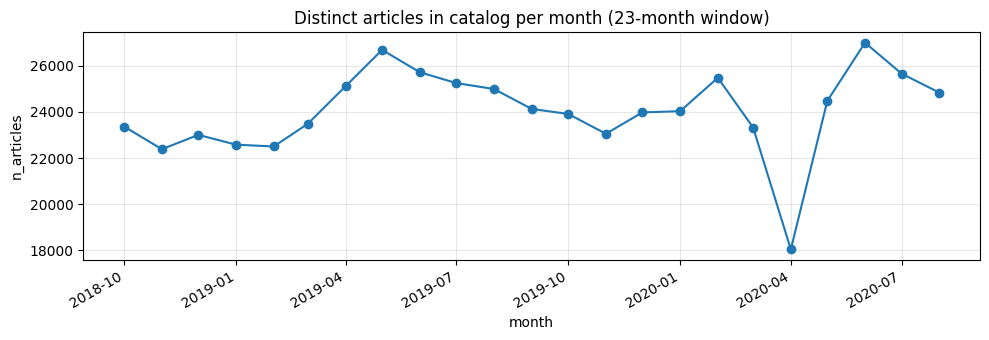

In [9]:
articles_per_month = (
    fp_disk.groupby('month', observed=True)['n_articles']
           .sum()
           .sort_index()
)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(articles_per_month.index, articles_per_month.values, marker='o', linewidth=1.5)
ax.set_title('Distinct articles in catalog per month (23-month window)')
ax.set_ylabel('n_articles')
ax.set_xlabel('month')
ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout(); plt.show()


top-5 master colors by mean share: ['Black', 'Blue', 'White', 'Grey', 'Beige']


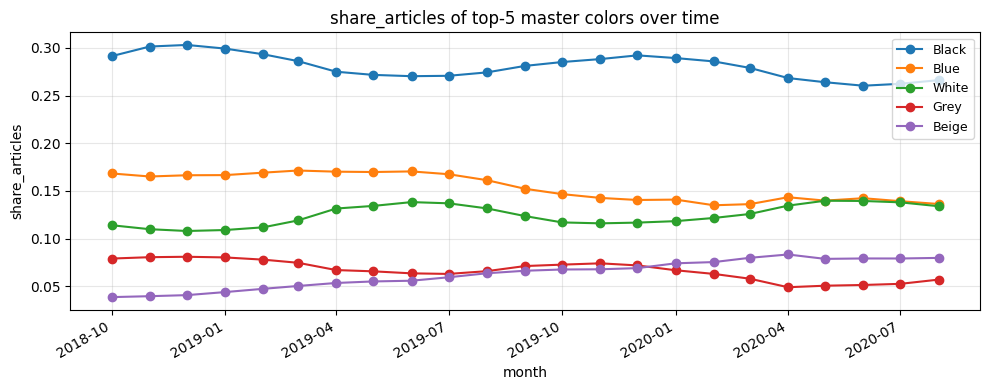

In [10]:
colors = uv_disk[uv_disk['dimension'] == 'color_master'].copy()
colors['name'] = decode('color_master', colors['level_id'])

top5 = (
    colors.groupby('name', observed=True)['share_articles']
          .mean()
          .sort_values(ascending=False)
          .head(5)
          .index.tolist()
)
print(f'top-5 master colors by mean share: {top5}')

fig, ax = plt.subplots(figsize=(10, 4))
for name in top5:
    sub = colors[colors['name'] == name].sort_values('month')
    ax.plot(sub['month'], sub['share_articles'], marker='o', linewidth=1.5, label=name)
ax.set_title('share_articles of top-5 master colors over time')
ax.set_ylabel('share_articles')
ax.set_xlabel('month')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout(); plt.show()


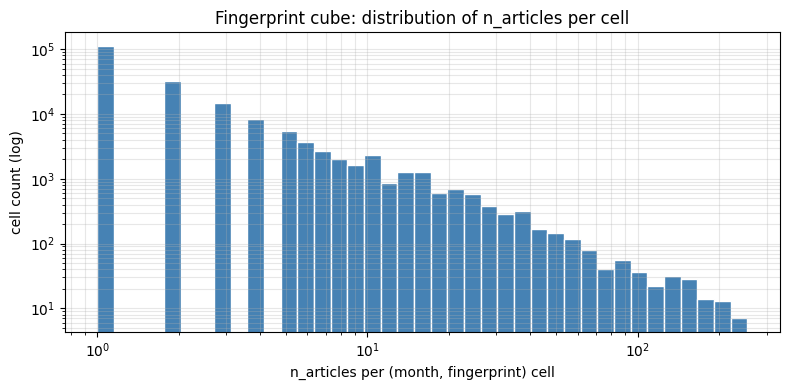

cell-size summary:
count    192471.00
mean          2.87
std           6.34
min           1.00
50%           1.00
90%           6.00
99%          25.00
max         254.00
Name: n_articles, dtype: float64


In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.logspace(0, np.log10(fp_disk['n_articles'].max() + 1), 40)
ax.hist(fp_disk['n_articles'], bins=bins, color='steelblue', edgecolor='white')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Fingerprint cube: distribution of n_articles per cell')
ax.set_xlabel('n_articles per (month, fingerprint) cell')
ax.set_ylabel('cell count (log)')
ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

print('cell-size summary:')
print(fp_disk['n_articles'].describe(percentiles=[0.5, 0.9, 0.99]).round(2))


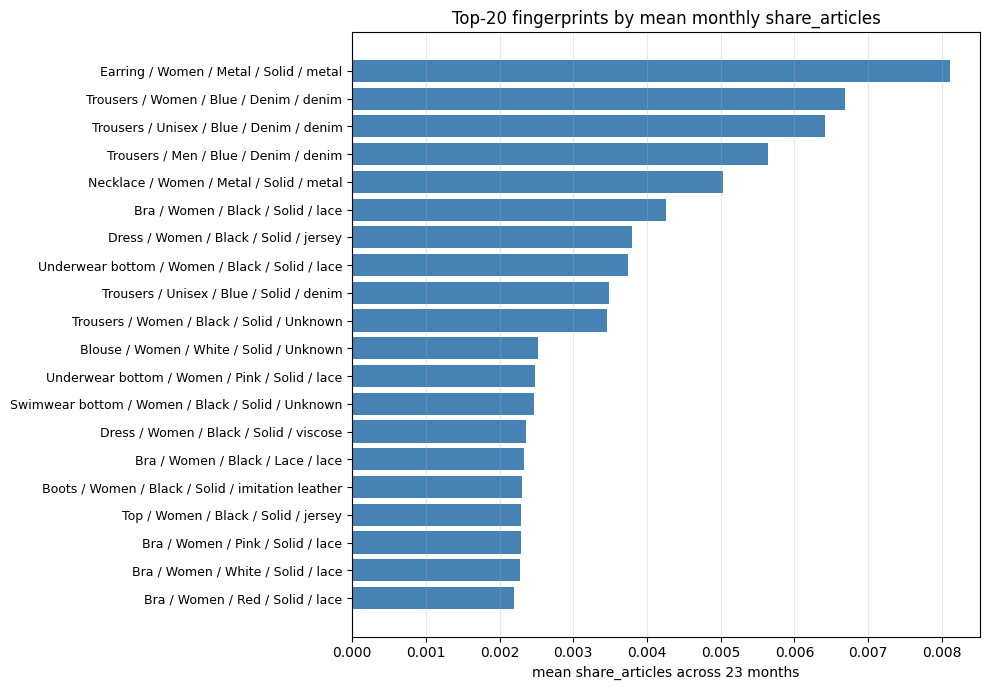

In [12]:
top_fp = (
    fp_disk.groupby(FINGERPRINT_COLS, observed=True)['share_articles']
           .mean()
           .sort_values(ascending=False)
           .head(20)
           .reset_index()
)

label_dims = [
    ('product_type_id', 'product_type'),
    ('gender_id', 'gender'),
    ('color_master_id', 'color_master'),
    ('graphical_appearance_id', 'graphical_appearance'),
    ('material_id', 'material'),
]
labels = top_fp.apply(
    lambda r: ' / '.join(decode(cat, pd.Series([r[idc]])).iloc[0] for idc, cat in label_dims),
    axis=1,
)

fig, ax = plt.subplots(figsize=(10, 7))
y = np.arange(len(top_fp))
ax.barh(y, top_fp['share_articles'].values, color='steelblue')
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('mean share_articles across 23 months')
ax.set_title('Top-20 fingerprints by mean monthly share_articles')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout(); plt.show()


In [13]:
fp_disk = pd.read_parquet(OUT_FINGERPRINT)
fp_disk.sort_values('share_articles', ascending=False)

,month,month_of_year,source,product_type_id,gender_id,color_master_id,graphical_appearance_id,material_id,n_articles,share_articles,avg_price
190704,2020-08-01,8,historical,26,1,12,1,7,246,0.009906,0.011656
74090,2019-06-01,6,historical,26,1,12,1,7,254,0.009878,0.012613
182367,2020-07-01,7,historical,26,1,12,1,7,250,0.009745,0.010940
82602,2019-07-01,7,historical,26,1,12,1,7,241,0.009547,0.012426
184526,2020-08-01,8,historical,1,2,2,3,3,225,0.009061,0.047196
...,...,...,...,...,...,...,...,...,...,...,...
173036,2020-06-01,6,historical,18,1,10,0,0,1,0.000037,0.067780
173038,2020-06-01,6,historical,18,1,10,5,1,1,0.000037,0.027102
173039,2020-06-01,6,historical,18,1,10,7,0,1,0.000037,0.067780
173041,2020-06-01,6,historical,18,1,11,1,12,1,0.000037,0.067780


In [14]:
uv_disk = pd.read_parquet(OUT_UNIVARIATE)
uv_disk.head(20)

,month,month_of_year,source,dimension,level_id,n_articles,share_articles
0,2018-10-01,10,historical,product_type,1,2425,0.103810
1,2018-10-01,10,historical,product_type,2,2184,0.093493
2,2018-10-01,10,historical,product_type,3,2611,0.111772
3,2018-10-01,10,historical,product_type,4,1619,0.069307
4,2018-10-01,10,historical,product_type,5,1032,0.044178
5,2018-10-01,10,historical,product_type,6,1384,0.059247
6,2018-10-01,10,historical,product_type,7,805,0.034461
7,2018-10-01,10,historical,product_type,8,815,0.034889
8,2018-10-01,10,historical,product_type,9,283,0.012115
9,2018-10-01,10,historical,product_type,10,315,0.013485
